# RL Group Project: Starter Notebook
## Clinical Treatment Optimisation: Sepsis ICU Management

**Master in Data Science & Advanced Analytics — Reinforcement Learning Course**

This project is structured in two stages of increasing complexity.

- In **Configuration A**, you will work with a tabular Sepsis MDP, where the state and action spaces are small enough to apply classical RL methods directly. 

- In **Configuration B**, you will move to a continuous-observation ICU environment that is clinically grounded and significantly more challenging. 

Three realistic failure modes are present in Configuration B, each reflecting a real scenario encountered in clinical AI deployments. The first is episodic observation noise, where monitoring equipment occasionally malfunctions. The second is episodic missing observations, representing situations where lab results are simply unavailable for an entire episode. The third is acute clinical events, which are sudden and irreversible patient deteriorations that occur independently of any treatment given.


---
### Group Members
Group V

```
Student 1: Alano Gonçalves 20250457
Student 2: Catarina Martins 20221914
Student 3: João Carichas 20250507
Student 4: Marta Ribeiro 20221886
Student 5: Nicole Nogueira 20221961
```


## 0. Setup & Imports


In [1]:
# Install dependencies (run once)
#!pip install icu-sepsis numpy pandas matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
import os
import sys
from tqdm import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

os.makedirs('plots', exist_ok=True)
PLOTS_DIR = 'plots'

SEED = 42
np.random.seed(SEED)

#  Import constants and env factory from env_setup.py 
from envs.env_setup import (
    ENV_ID, N_STATES, N_ACTIONS, STATE_SURVIVED, STATE_DIED,
    GAMMA, INTENSITY, SOFA_BIAS, LAM,
    make_sepsis_env,
)

print(f'ICU-Sepsis-v2 | States: {N_STATES} | Actions: {N_ACTIONS}')
print(f'Terminal states: {STATE_SURVIVED} (survived, r=+1)  {STATE_DIED} (died, r=0)')
print('Setup complete!')


ICU-Sepsis-v2 | States: 716 | Actions: 25
Terminal states: 714 (survived, r=+1)  713 (died, r=0)
Setup complete!


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
# Configuration already loaded from env_setup.py
# env_setup.py defines: SOFA_BIAS=5.0, LAM=0.02, INTENSITY, make_sepsis_env()
print(f'Required config: sofa_bias={SOFA_BIAS}, lam={LAM}')

Required config: sofa_bias=5.0, lam=0.02


---
## 1. Explore the Environment

Before writing any algorithm, take time to understand the MDP you are working with. The insights you gain here should inform your report's Methodology section.

`ICU-Sepsis-v2` is a benchmark MDP constructed from real MIMIC-III patient data. Each episode represents the trajectory of one ICU patient. The agent observes a discrete integer state (ranging from 0 to 715) and must select one of 25 treatment actions corresponding to combinations of vasopressor and IV fluid dose levels. The reward signal is sparse: **+1 at survival, 0 at death, and 0 for all intermediate steps**, with a discount factor γ = 1.


In [3]:
#  Instantiate and inspect the raw environment 
env = make_sepsis_env()
obs, info = env.reset(seed=SEED)

print(f'Observation space : {env.observation_space} discrete integer state')
print(f'Action space      : {env.action_space}')
print(f'Initial state     : {obs}')
print()

#  Extract the full MDP model 
raw = env.unwrapped
P = raw._tx_mat    # shape (716, 25, 716) — P[s,a,s'] = P(s'|s,a)
R_sasp = raw._r_mat                    # (716, 25, 716) — R[s, a, s']
R = (P * R_sasp).sum(axis=2)          # (716, 25)      — E[r | s, a]

print(f'Transition matrix P : {P.shape}  (S × A × S\')')
print(f'Reward matrix R     : {R.shape}  (S × A)')
print(f'Reward range        : [{R.min():.3f}, {R.max():.3f}]')
print()


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Observation space : Discrete(716) discrete integer state
Action space      : Discrete(25)
Initial state     : 559

Transition matrix P : (716, 25, 716)  (S × A × S')
Reward matrix R     : (716, 25)  (S × A)
Reward range        : [-0.020, 0.708]



In [4]:
#  Random baseline: establish the performance floor 
def run_random_baseline(n_episodes=1000, seed=SEED):
    np.random.seed(seed)
    env_eval = make_sepsis_env()
    returns, lengths = [], []
    for _ in range(n_episodes):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        total_r, steps, done = 0.0, 0, False
        while not done:
            obs, r, te, tr, _ = env_eval.step(env_eval.action_space.sample())
            total_r += r; steps += 1; done = te or tr
        returns.append(total_r)
        lengths.append(steps)
    env_eval.close()
    return np.array(returns), np.array(lengths)


rand_returns, rand_lengths = run_random_baseline()
survival_rate = float(np.mean(rand_returns > 0)) * 100

print(f'Random agent ({len(rand_returns)} episodes):')
print(f'  Mean return    : {np.mean(rand_returns):.4f}')
print(f'  Survival rate  : {survival_rate:.1f}%')
print(f'  Mean ep length : {np.mean(rand_lengths):.1f} steps')
print()
print('All Config A algorithms must beat the random baseline.')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Random agent (1000 episodes):
  Mean return    : 0.5787
  Survival rate  : 68.1%
  Mean ep length : 10.2 steps

All Config A algorithms must beat the random baseline.


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


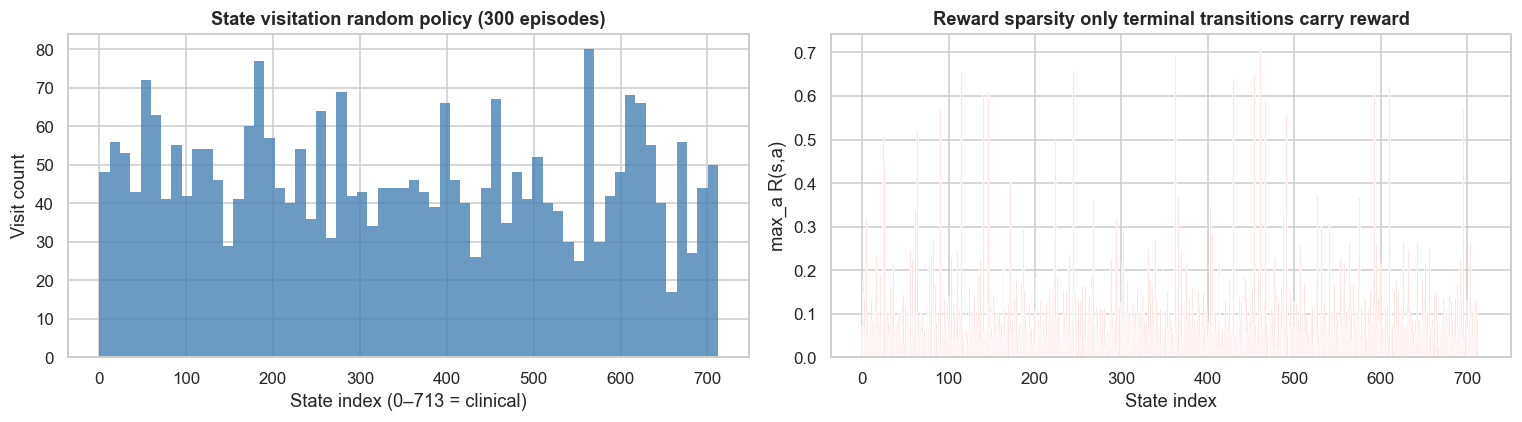

In [5]:
#  Visualise state visitation and reward structure 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# State visitation under random policy
np.random.seed(SEED)
env_vis = make_sepsis_env()
visited = []
for _ in range(300):
    obs, _ = env_vis.reset(seed=np.random.randint(100_000))
    done = False
    while not done:
        visited.append(int(obs))
        obs, _, te, tr, _ = env_vis.step(env_vis.action_space.sample())
        done = te or tr
env_vis.close()
clinical = [s for s in visited if s not in (STATE_SURVIVED, STATE_DIED)]

axes[0].hist(clinical, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_xlabel('State index (0–713 = clinical)')
axes[0].set_ylabel('Visit count')
axes[0].set_title('State visitation random policy (300 episodes)', fontweight='bold')

# Max achievable reward per state (only survival-adjacent states have r > 0)
axes[1].bar(range(N_STATES), R.max(axis=1), color='tomato', width=1.0, alpha=0.8)
axes[1].set_xlabel('State index')
axes[1].set_ylabel('max_a R(s,a)')
axes[1].set_title('Reward sparsity only terminal transitions carry reward',
                  fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_env_exploration.png', bbox_inches='tight')
plt.show()


---
# Config A — Tabular Methods

With 716 discrete states and 25 actions, the Q-table has shape `(716, 25)`, totalling 17,900 entries. This size is entirely manageable in memory, which is precisely what motivates the use of tabular algorithms here.

We have decided to implement three algorithms in Config A:
- **Policy Iteration (PI)**: a model-based Dynamic Programming method that uses the full MDP (transition matrix P and reward matrix R) to find the theoretically optimal policy. Serves as the performance ceiling.
- **SARSA**: an on-policy, model-free TD algorithm. Learns from environment interaction; its updates use the action the agent actually takes next, making it conservative.
- **Q-Learning**: an off-policy, model-free TD algorithm. Also learns from interaction but always updates towards the best possible next action, making it more aggressive.

The natural contrast: **PI** has access to the full model (unfair advantage but gives us the optimal ceiling), while **SARSA and Q-Learning** must discover the policy through trial and error. Within the model-free pair, the **on-policy vs off-policy** distinction maps directly onto clinical conservatism: an agent that accounts for its own exploratory uncertainty (SARSA) vs one that assumes it will always act optimally (Q-Learning).


## 2. Policy Iteration

Policy Iteration is a Dynamic Programming method that alternates between two steps:
1. **Policy Evaluation**: given the current policy, compute V(s) for all states using the Bellman expectation equation iteratively.
2. **Policy Improvement**: for each state, update the policy to the action that maximises the expected value.

Because the full MDP (P and R) is available in Config A, PI finds the exact optimal policy without any interaction with the environment. This makes it the **theoretical ceiling** against which we measure our model-free agents.

In [6]:
# ── Policy Iteration ──────────────────────────────────────────────────────────

def policy_iteration(P, R, gamma=1.0, theta=1e-8, max_iter=1000):
    """
    Exact Policy Iteration using the full MDP matrices.

    Parameters
    ----------
    P     : np.ndarray (S, A, S') — transition probabilities
    R     : np.ndarray (S, A)     — expected reward per state-action
    gamma : float                 — discount factor
    theta : float                 — convergence threshold for policy evaluation
    max_iter : int                — max policy improvement iterations

    Returns
    -------
    policy      : np.ndarray (S,) — optimal action per state
    V           : np.ndarray (S,) — optimal value function
    n_iter      : int             — number of policy improvement iterations
    delta_history : list          — max delta per evaluation sweep (for plotting)
    """
    n_states, n_actions, _ = P.shape

    # Initialise with a random policy
    policy = np.zeros(n_states, dtype=int)
    V = np.zeros(n_states)
    delta_history = []

    for iteration in range(max_iter):

        # ── Step 1: Policy Evaluation ────────────────────────────────────────
        # Iteratively compute V(s) for all s under the current policy
        while True:
            delta = 0.0
            for s in range(n_states):
                a = policy[s]
                # Bellman expectation: V(s) = R(s,a) + gamma * sum_s' P(s'|s,a)*V(s')
                v_new = R[s, a] + gamma * np.dot(P[s, a], V)
                delta = max(delta, abs(v_new - V[s]))
                V[s] = v_new
            delta_history.append(delta)
            if delta < theta:
                break

        # ── Step 2: Policy Improvement ───────────────────────────────────────
        # For each state, greedily pick the action with highest Q(s,a)
        policy_stable = True
        for s in range(n_states):
            old_action = policy[s]
            # Q(s,a) = R(s,a) + gamma * sum_s' P(s'|s,a)*V(s')
            Q_s = R[s] + gamma * P[s].dot(V)   # shape (A,)
            policy[s] = np.argmax(Q_s)
            if old_action != policy[s]:
                policy_stable = False

        if policy_stable:
            print(f'Policy Iteration converged after {iteration + 1} improvement iterations.')
            break

    return policy, V, iteration + 1, delta_history


# Run Policy Iteration
np.random.seed(SEED)
pi_policy, pi_V, pi_iters, pi_deltas = policy_iteration(P, R, gamma=GAMMA)

print(f'Value function range: [{pi_V.min():.4f}, {pi_V.max():.4f}]')
print(f'Unique actions used by PI policy: {len(np.unique(pi_policy))}/25')


Policy Iteration converged after 4 improvement iterations.
Value function range: [0.0000, 0.9814]
Unique actions used by PI policy: 15/25


In [7]:
# ── Evaluate Policy Iteration ─────────────────────────────────────────────────

def evaluate_policy_tabular(policy_array, n_episodes=1000, seed=SEED):
    """
    Evaluate a deterministic tabular policy over n_episodes.
    policy_array : np.ndarray (N_STATES,) — action index per state
    Returns mean return, survival rate, mean episode length.
    """
    np.random.seed(seed)
    env_eval = make_sepsis_env()
    returns, lengths = [], []

    for _ in range(n_episodes):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        total_r, steps, done = 0.0, 0, False
        while not done:
            action = int(policy_array[int(obs)])
            obs, r, te, tr, _ = env_eval.step(action)
            total_r += r
            steps += 1
            done = te or tr
        returns.append(total_r)
        lengths.append(steps)

    env_eval.close()
    returns = np.array(returns)
    return {
        'mean_return'   : float(np.mean(returns)),
        'survival_rate' : float(np.mean(returns > 0)) * 100,
        'mean_length'   : float(np.mean(lengths)),
    }


pi_results = evaluate_policy_tabular(pi_policy)
print('Policy Iteration — Evaluation (1000 episodes):')
print(f'  Mean return   : {pi_results["mean_return"]:.4f}')
print(f'  Survival rate : {pi_results["survival_rate"]:.1f}%')
print(f'  Mean length   : {pi_results["mean_length"]:.1f} steps')
print(f'  vs Random baseline survival: {survival_rate:.1f}%')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Policy Iteration — Evaluation (1000 episodes):
  Mean return   : 0.7507
  Survival rate : 78.8%
  Mean length   : 9.8 steps
  vs Random baseline survival: 68.1%


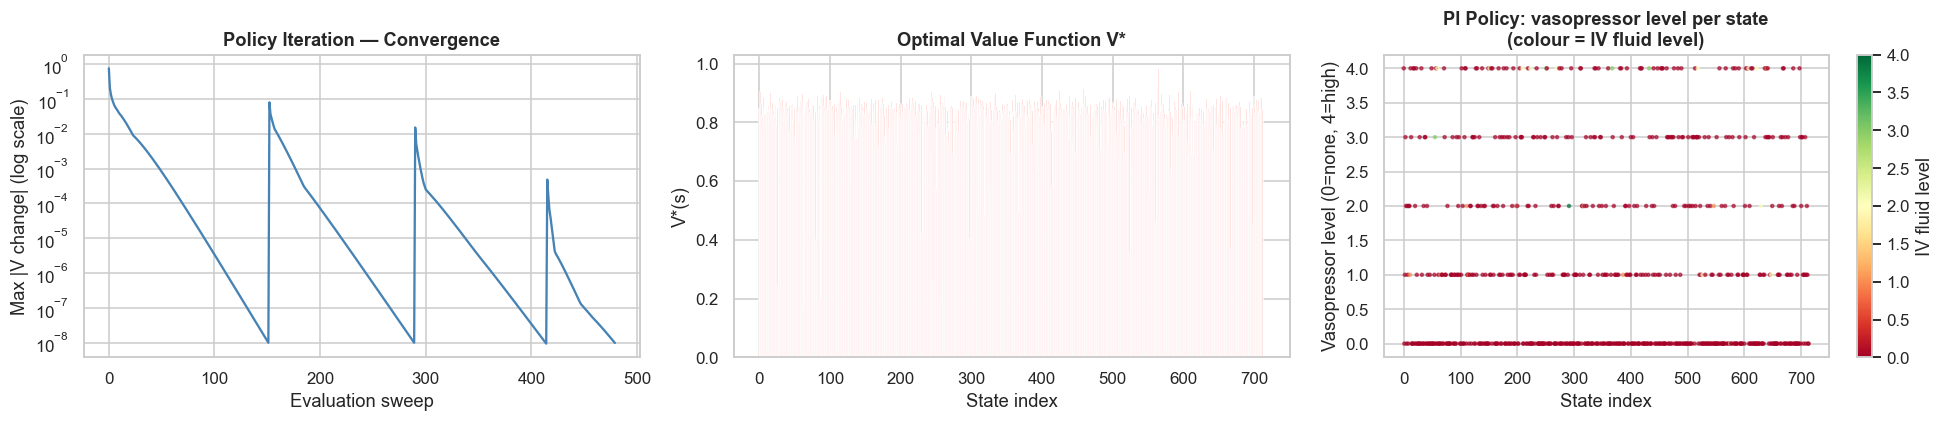

In [8]:
# ── Plot PI: convergence + value function + policy heatmap ───────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. Convergence: max delta per evaluation sweep
axes[0].semilogy(pi_deltas, color='steelblue', linewidth=1.5)
axes[0].set_xlabel('Evaluation sweep')
axes[0].set_ylabel('Max |V change| (log scale)')
axes[0].set_title('Policy Iteration — Convergence', fontweight='bold')

# 2. Optimal value function across clinical states
clinical_states = [s for s in range(N_STATES) if s not in (STATE_SURVIVED, STATE_DIED)]
axes[1].bar(clinical_states, pi_V[clinical_states], color='tomato', width=1.0, alpha=0.8)
axes[1].set_xlabel('State index')
axes[1].set_ylabel('V*(s)')
axes[1].set_title('Optimal Value Function V*', fontweight='bold')

# 3. Policy heatmap: action chosen per state (25 actions = 5 vaso x 5 fluid)
# Reshape policy into a grid for visualisation
policy_display = pi_policy[:714]   # clinical states only
# Interpret action as (vaso_level, fluid_level): action = vaso*5 + fluid
vaso_levels  = policy_display // 5
fluid_levels = policy_display  % 5

axes[2].scatter(range(len(policy_display)), vaso_levels,
                c=fluid_levels, cmap='RdYlGn', s=4, alpha=0.6)
axes[2].set_xlabel('State index')
axes[2].set_ylabel('Vasopressor level (0=none, 4=high)')
axes[2].set_title('PI Policy: vasopressor level per state\n(colour = IV fluid level)', fontweight='bold')
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(0, 4))
plt.colorbar(sm, ax=axes[2], label='IV fluid level')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_PI.png', bbox_inches='tight')
plt.show()


## 3. SARSA (On-Policy TD Control)

SARSA (**S**tate–**A**ction–**R**eward–next **S**tate–next **A**ction) is a model-free, on-policy TD control algorithm. At each step it uses the sequence `(s, a, r, s', a')` to update the Q-value:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \bigl[r + \gamma\, Q(s', a') - Q(s,a)\bigr]$$

The key: **a' is selected by the same epsilon-greedy policy** the agent is currently following. This means SARSA's updates account for the risk of future exploratory (random) actions — making it naturally more conservative than Q-Learning. In a clinical context this conservatism is desirable: the agent effectively learns a policy that is safe even while it is still uncertain.


In [9]:
# ── SARSA ─────────────────────────────────────────────────────────────────────

def sarsa(
    n_episodes=50_000,
    alpha=0.3,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.01,
    seed=SEED,
):
    """
    SARSA on-policy TD control for the tabular Sepsis MDP.

    Parameters
    ----------
    n_episodes    : int   — number of training episodes
    alpha         : float — learning rate
    gamma         : float — discount factor
    epsilon_start : float — initial exploration probability
    epsilon_min   : float — minimum exploration probability
    seed          : int   — random seed

    Returns
    -------
    Q            : np.ndarray (N_STATES, N_ACTIONS) — learned Q-table
    returns_log  : list of float — episode returns during training
    """
    np.random.seed(seed)
    env_train = make_sepsis_env()

    Q = np.zeros((N_STATES, N_ACTIONS))
    returns_log = []
    epsilon = epsilon_start
    decay = (epsilon_start - epsilon_min) / n_episodes

    for ep in tqdm(range(n_episodes), desc='SARSA', leave=False):
        obs, _ = env_train.reset(seed=np.random.randint(100_000))
        s = int(obs)

        # Select first action with epsilon-greedy
        if np.random.random() < epsilon:
            a = env_train.action_space.sample()
        else:
            a = int(np.argmax(Q[s]))

        total_r, done = 0.0, False

        while not done:
            obs_next, r, te, tr, _ = env_train.step(a)
            s_next = int(obs_next)
            done = te or tr

            # Select next action (on-policy: epsilon-greedy)
            if np.random.random() < epsilon:
                a_next = env_train.action_space.sample()
            else:
                a_next = int(np.argmax(Q[s_next]))

            # SARSA update — uses actual next action a_next
            td_target = r + gamma * Q[s_next, a_next] * (not done)
            Q[s, a] += alpha * (td_target - Q[s, a])

            s, a = s_next, a_next
            total_r += r

        returns_log.append(total_r)
        # Decay epsilon after each episode
        epsilon = max(epsilon_min, epsilon - decay)

    env_train.close()
    return Q, returns_log


# Run SARSA
SARSA_N_EPISODES = 50_000
sarsa_Q, sarsa_returns = sarsa(
    n_episodes=SARSA_N_EPISODES,
    alpha=0.3,
    gamma=GAMMA,
    epsilon_start=1.0,
    epsilon_min=0.01,
)

sarsa_policy = np.argmax(sarsa_Q, axis=1)
print('SARSA training complete.')
print(f'Unique actions used: {len(np.unique(sarsa_policy))}/25')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


SARSA training complete.
Unique actions used: 25/25


In [10]:
# ── Evaluate SARSA ────────────────────────────────────────────────────────────
sarsa_results = evaluate_policy_tabular(sarsa_policy)
print('SARSA — Evaluation (1000 episodes):')
print(f'  Mean return   : {sarsa_results["mean_return"]:.4f}')
print(f'  Survival rate : {sarsa_results["survival_rate"]:.1f}%')
print(f'  Mean length   : {sarsa_results["mean_length"]:.1f} steps')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
SARSA — Evaluation (1000 episodes):
  Mean return   : 0.6261
  Survival rate : 72.3%
  Mean length   : 10.4 steps


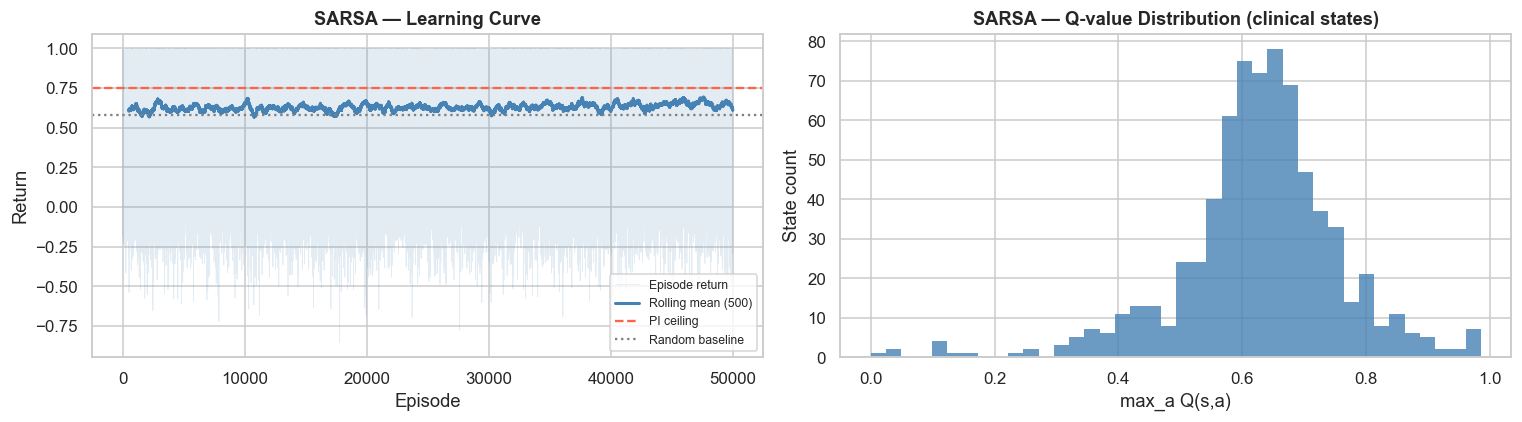

In [11]:
# ── Plot SARSA: learning curve + Q-value distribution ────────────────────────

window = 500
sarsa_rolling = pd.Series(sarsa_returns).rolling(window).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Learning curve
axes[0].plot(sarsa_returns, alpha=0.15, color='steelblue', linewidth=0.5, label='Episode return')
axes[0].plot(sarsa_rolling, color='steelblue', linewidth=2.0, label=f'Rolling mean ({window})')
axes[0].axhline(pi_results['mean_return'], color='tomato', linestyle='--', linewidth=1.5, label='PI ceiling')
axes[0].axhline(np.mean(rand_returns), color='gray', linestyle=':', linewidth=1.5, label='Random baseline')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Return')
axes[0].set_title('SARSA — Learning Curve', fontweight='bold')
axes[0].legend(fontsize=8)

# Q-value distribution (max Q per state, clinical states only)
max_Q_sarsa = sarsa_Q[:714].max(axis=1)
axes[1].hist(max_Q_sarsa, bins=40, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].set_xlabel('max_a Q(s,a)')
axes[1].set_ylabel('State count')
axes[1].set_title('SARSA — Q-value Distribution (clinical states)', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_SARSA.png', bbox_inches='tight')
plt.show()


## 4. Q-Learning (Off-Policy TD Control)

Q-Learning is a model-free, **off-policy** TD control algorithm. Its update rule differs from SARSA in one crucial place — instead of using the action the agent actually takes next (`a'`), it always bootstraps from the **maximum** Q-value in the next state:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \bigl[r + \gamma \max_{a'} Q(s', a') - Q(s,a)\bigr]$$

This means Q-Learning learns the value of the **greedy policy** regardless of how the agent actually behaves during training. It tends to converge to a more aggressive optimal policy, but may overestimate Q-values because it always assumes the best possible future (maximisation bias).

In the clinical context: Q-Learning may recommend higher-intensity interventions. Comparing its policy to SARSA's will reveal whether aggressive treatment strategies actually improve survival in this dataset.


In [12]:
# ── Q-Learning ────────────────────────────────────────────────────────────────

def q_learning(
    n_episodes=50_000,
    alpha=0.3,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.01,
    seed=SEED,
):
    """
    Q-Learning off-policy TD control for the tabular Sepsis MDP.

    Parameters
    ----------
    n_episodes    : int   — number of training episodes
    alpha         : float — learning rate
    gamma         : float — discount factor
    epsilon_start : float — initial exploration probability
    epsilon_min   : float — minimum exploration probability
    seed          : int   — random seed

    Returns
    -------
    Q            : np.ndarray (N_STATES, N_ACTIONS) — learned Q-table
    returns_log  : list of float — episode returns during training
    """
    np.random.seed(seed)
    env_train = make_sepsis_env()

    Q = np.zeros((N_STATES, N_ACTIONS))
    returns_log = []
    epsilon = epsilon_start
    decay = (epsilon_start - epsilon_min) / n_episodes

    for ep in tqdm(range(n_episodes), desc='Q-Learning', leave=False):
        obs, _ = env_train.reset(seed=np.random.randint(100_000))
        s = int(obs)
        total_r, done = 0.0, False

        while not done:
            # Select action with epsilon-greedy
            if np.random.random() < epsilon:
                a = env_train.action_space.sample()
            else:
                a = int(np.argmax(Q[s]))

            obs_next, r, te, tr, _ = env_train.step(a)
            s_next = int(obs_next)
            done = te or tr

            # Q-Learning update — uses max over next actions (off-policy)
            td_target = r + gamma * np.max(Q[s_next]) * (not done)
            Q[s, a] += alpha * (td_target - Q[s, a])

            s = s_next
            total_r += r

        returns_log.append(total_r)
        epsilon = max(epsilon_min, epsilon - decay)

    env_train.close()
    return Q, returns_log


# Run Q-Learning
QL_N_EPISODES = 50_000
ql_Q, ql_returns = q_learning(
    n_episodes=QL_N_EPISODES,
    alpha=0.3,
    gamma=GAMMA,
    epsilon_start=1.0,
    epsilon_min=0.01,
)

ql_policy = np.argmax(ql_Q, axis=1)
print('Q-Learning training complete.')
print(f'Unique actions used: {len(np.unique(ql_policy))}/25')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


Q-Learning training complete.
Unique actions used: 25/25


In [13]:
# ── Evaluate Q-Learning ───────────────────────────────────────────────────────
ql_results = evaluate_policy_tabular(ql_policy)
print('Q-Learning — Evaluation (1000 episodes):')
print(f'  Mean return   : {ql_results["mean_return"]:.4f}')
print(f'  Survival rate : {ql_results["survival_rate"]:.1f}%')
print(f'  Mean length   : {ql_results["mean_length"]:.1f} steps')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Q-Learning — Evaluation (1000 episodes):
  Mean return   : 0.6343
  Survival rate : 71.9%
  Mean length   : 10.6 steps


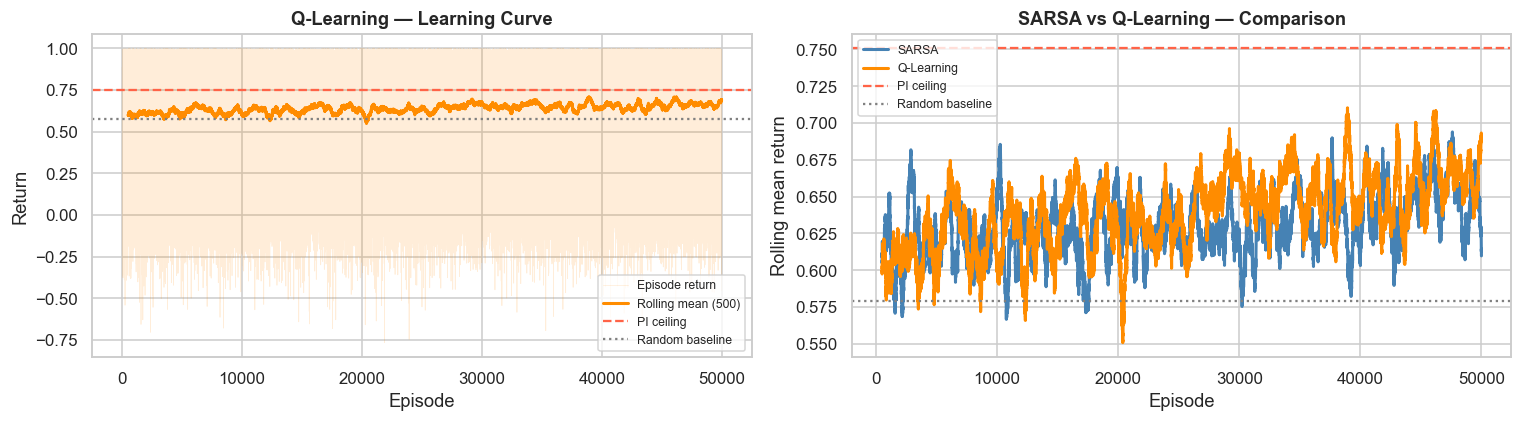

In [14]:
# ── Plot Q-Learning: learning curve + SARSA vs QL overlay ────────────────────

window = 500
ql_rolling   = pd.Series(ql_returns).rolling(window).mean()
sarsa_rolling_full = pd.Series(sarsa_returns).rolling(window).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Q-Learning learning curve alone
axes[0].plot(ql_returns, alpha=0.15, color='darkorange', linewidth=0.5, label='Episode return')
axes[0].plot(ql_rolling, color='darkorange', linewidth=2.0, label=f'Rolling mean ({window})')
axes[0].axhline(pi_results['mean_return'], color='tomato', linestyle='--', linewidth=1.5, label='PI ceiling')
axes[0].axhline(np.mean(rand_returns), color='gray', linestyle=':', linewidth=1.5, label='Random baseline')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Return')
axes[0].set_title('Q-Learning — Learning Curve', fontweight='bold')
axes[0].legend(fontsize=8)

# Head-to-head: SARSA vs Q-Learning rolling mean
axes[1].plot(sarsa_rolling_full, color='steelblue', linewidth=2.0, label='SARSA')
axes[1].plot(ql_rolling, color='darkorange', linewidth=2.0, label='Q-Learning')
axes[1].axhline(pi_results['mean_return'], color='tomato', linestyle='--', linewidth=1.5, label='PI ceiling')
axes[1].axhline(np.mean(rand_returns), color='gray', linestyle=':', linewidth=1.5, label='Random baseline')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Rolling mean return')
axes[1].set_title('SARSA vs Q-Learning — Comparison', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_QL.png', bbox_inches='tight')
plt.show()


## 5. Creative Extension: Double Q-Learning

Standard Q-Learning suffers from **maximisation bias**: because it always bootstraps from `max Q(s', .)`, it systematically overestimates action values when the Q-table contains noise. In a medical context this matters — overestimating the value of an aggressive treatment could lead the agent to over-prescribe vasopressors or fluids even when moderate doses are sufficient.

**Double Q-Learning** (Hasselt, 2010) addresses this by maintaining **two independent Q-tables** (`Q_A` and `Q_B`). At each step:
- With probability 0.5, use `Q_A` to *select* the best next action, but `Q_B` to *evaluate* it — and update `Q_A`.
- Otherwise do the reverse.

This decoupling of action selection from action evaluation removes the upward bias. We expect Double Q-Learning to produce a **more conservative treatment policy** than standard Q-Learning, which is clinically desirable.


In [15]:
# ── Double Q-Learning ─────────────────────────────────────────────────────────

def double_q_learning(
    n_episodes=50_000,
    alpha=0.3,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.01,
    seed=SEED,
):
    """
    Double Q-Learning to reduce maximisation bias.

    Maintains two Q-tables (Q_A, Q_B). At each step, randomly chooses
    which table to update, using the other for evaluation.

    Parameters
    ----------
    n_episodes    : int   — number of training episodes
    alpha         : float — learning rate
    gamma         : float — discount factor
    epsilon_start : float — initial exploration probability
    epsilon_min   : float — minimum exploration probability
    seed          : int   — random seed

    Returns
    -------
    Q_avg        : np.ndarray (N_STATES, N_ACTIONS) — average of Q_A and Q_B
    returns_log  : list of float — episode returns during training
    """
    np.random.seed(seed)
    env_train = make_sepsis_env()

    Q_A = np.zeros((N_STATES, N_ACTIONS))
    Q_B = np.zeros((N_STATES, N_ACTIONS))
    returns_log = []
    epsilon = epsilon_start
    decay = (epsilon_start - epsilon_min) / n_episodes

    for ep in tqdm(range(n_episodes), desc='Double Q-Learning', leave=False):
        obs, _ = env_train.reset(seed=np.random.randint(100_000))
        s = int(obs)
        total_r, done = 0.0, False

        while not done:
            # Action selection uses the sum of both tables
            Q_sum = Q_A[s] + Q_B[s]
            if np.random.random() < epsilon:
                a = env_train.action_space.sample()
            else:
                a = int(np.argmax(Q_sum))

            obs_next, r, te, tr, _ = env_train.step(a)
            s_next = int(obs_next)
            done = te or tr

            # Randomly assign update to Q_A or Q_B
            if np.random.random() < 0.5:
                # Update Q_A: select action with Q_A, evaluate with Q_B
                best_a_next = int(np.argmax(Q_A[s_next]))
                td_target = r + gamma * Q_B[s_next, best_a_next] * (not done)
                Q_A[s, a] += alpha * (td_target - Q_A[s, a])
            else:
                # Update Q_B: select action with Q_B, evaluate with Q_A
                best_a_next = int(np.argmax(Q_B[s_next]))
                td_target = r + gamma * Q_A[s_next, best_a_next] * (not done)
                Q_B[s, a] += alpha * (td_target - Q_B[s, a])

            s = s_next
            total_r += r

        returns_log.append(total_r)
        epsilon = max(epsilon_min, epsilon - decay)

    env_train.close()
    Q_avg = (Q_A + Q_B) / 2.0
    return Q_avg, returns_log


# Run Double Q-Learning
dql_Q, dql_returns = double_q_learning(
    n_episodes=50_000,
    alpha=0.3,
    gamma=GAMMA,
    epsilon_start=1.0,
    epsilon_min=0.01,
)

dql_policy = np.argmax(dql_Q, axis=1)
print('Double Q-Learning training complete.')
print(f'Unique actions used: {len(np.unique(dql_policy))}/25')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


Double Q-Learning training complete.
Unique actions used: 25/25


In [16]:
# ── Evaluate Double Q-Learning ────────────────────────────────────────────────
dql_results = evaluate_policy_tabular(dql_policy)
print('Double Q-Learning — Evaluation (1000 episodes):')
print(f'  Mean return   : {dql_results["mean_return"]:.4f}')
print(f'  Survival rate : {dql_results["survival_rate"]:.1f}%')
print(f'  Mean length   : {dql_results["mean_length"]:.1f} steps')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Double Q-Learning — Evaluation (1000 episodes):
  Mean return   : 0.6288
  Survival rate : 70.9%
  Mean length   : 9.8 steps


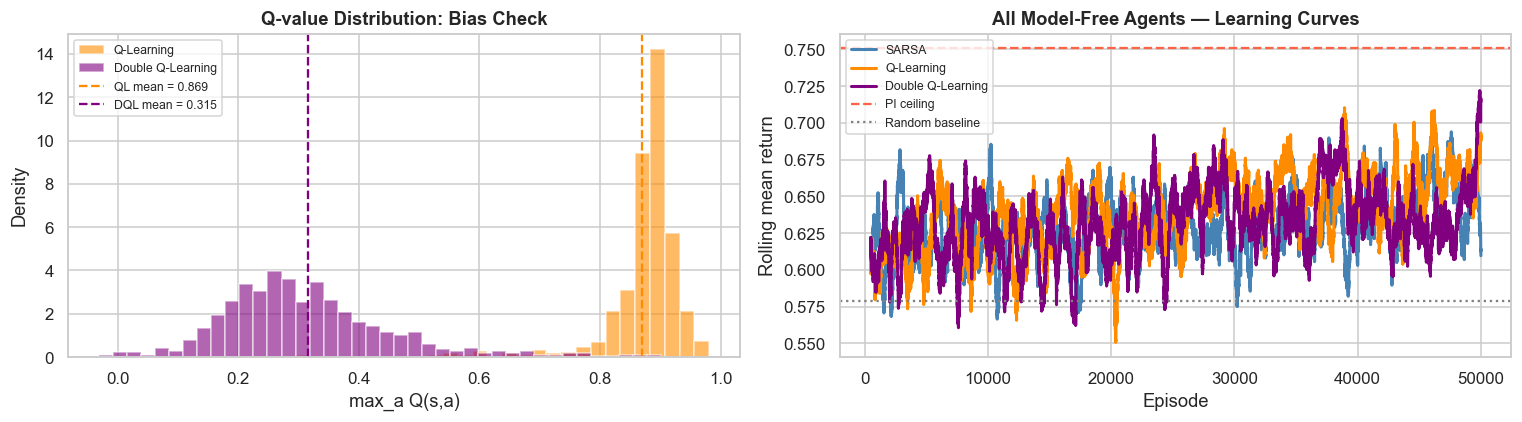

In [17]:
# ── Maximisation bias comparison: Q-Learning vs Double Q-Learning ─────────────
# Show Q-value distributions to reveal bias in standard Q-Learning

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Max Q-value per state — higher values in standard QL suggest overestimation
max_Q_ql  = ql_Q[:714].max(axis=1)
max_Q_dql = dql_Q[:714].max(axis=1)

axes[0].hist(max_Q_ql, bins=40, alpha=0.6, color='darkorange', label='Q-Learning', density=True)
axes[0].hist(max_Q_dql, bins=40, alpha=0.6, color='purple', label='Double Q-Learning', density=True)
axes[0].axvline(max_Q_ql.mean(), color='darkorange', linestyle='--', linewidth=1.5,
                label=f'QL mean = {max_Q_ql.mean():.3f}')
axes[0].axvline(max_Q_dql.mean(), color='purple', linestyle='--', linewidth=1.5,
                label=f'DQL mean = {max_Q_dql.mean():.3f}')
axes[0].set_xlabel('max_a Q(s,a)')
axes[0].set_ylabel('Density')
axes[0].set_title('Q-value Distribution: Bias Check', fontweight='bold')
axes[0].legend(fontsize=8)

# Learning curves: all three model-free methods
dql_rolling = pd.Series(dql_returns).rolling(500).mean()
axes[1].plot(sarsa_rolling_full, color='steelblue', linewidth=2.0, label='SARSA')
axes[1].plot(ql_rolling, color='darkorange', linewidth=2.0, label='Q-Learning')
axes[1].plot(dql_rolling, color='purple', linewidth=2.0, label='Double Q-Learning')
axes[1].axhline(pi_results['mean_return'], color='tomato', linestyle='--', linewidth=1.5, label='PI ceiling')
axes[1].axhline(np.mean(rand_returns), color='gray', linestyle=':', linewidth=1.5, label='Random baseline')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Rolling mean return')
axes[1].set_title('All Model-Free Agents — Learning Curves', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_DQL.png', bbox_inches='tight')
plt.show()


## 6. Final Comparison & Analysis

We now compare all four approaches:
- **Random baseline** — performance floor
- **Policy Iteration** — optimal ceiling (model-based)
- **SARSA** — on-policy, model-free, conservative
- **Q-Learning** — off-policy, model-free, aggressive
- **Double Q-Learning** — off-policy, model-free, bias-corrected


In [18]:
# ── Summary Results Table ─────────────────────────────────────────────────────

results_table = pd.DataFrame([
    {
        'Algorithm'       : 'Random Baseline',
        'Type'            : 'Baseline',
        'Needs Model'     : 'No',
        'Mean Return'     : round(float(np.mean(rand_returns)), 4),
        'Survival Rate %' : round(survival_rate, 1),
        'Mean Ep Length'  : round(float(np.mean(rand_lengths)), 1),
    },
    {
        'Algorithm'       : 'Policy Iteration',
        'Type'            : 'Dynamic Programming',
        'Needs Model'     : 'Yes',
        'Mean Return'     : round(pi_results['mean_return'], 4),
        'Survival Rate %' : round(pi_results['survival_rate'], 1),
        'Mean Ep Length'  : round(pi_results['mean_length'], 1),
    },
    {
        'Algorithm'       : 'SARSA',
        'Type'            : 'On-Policy TD',
        'Needs Model'     : 'No',
        'Mean Return'     : round(sarsa_results['mean_return'], 4),
        'Survival Rate %' : round(sarsa_results['survival_rate'], 1),
        'Mean Ep Length'  : round(sarsa_results['mean_length'], 1),
    },
    {
        'Algorithm'       : 'Q-Learning',
        'Type'            : 'Off-Policy TD',
        'Needs Model'     : 'No',
        'Mean Return'     : round(ql_results['mean_return'], 4),
        'Survival Rate %' : round(ql_results['survival_rate'], 1),
        'Mean Ep Length'  : round(ql_results['mean_length'], 1),
    },
    {
        'Algorithm'       : 'Double Q-Learning',
        'Type'            : 'Off-Policy TD (bias-corrected)',
        'Needs Model'     : 'No',
        'Mean Return'     : round(dql_results['mean_return'], 4),
        'Survival Rate %' : round(dql_results['survival_rate'], 1),
        'Mean Ep Length'  : round(dql_results['mean_length'], 1),
    },
])

display(results_table)
results_table.to_csv(f'{PLOTS_DIR}/configA_results_table.csv', index=False)


,Algorithm,Type,Needs Model,Mean Return,Survival Rate %,Mean Ep Length
0,Random Baseline,Baseline,No,0.5787,68.1,10.2
1,Policy Iteration,Dynamic Programming,Yes,0.7507,78.8,9.8
2,SARSA,On-Policy TD,No,0.6261,72.3,10.4
3,Q-Learning,Off-Policy TD,No,0.6343,71.9,10.6
4,Double Q-Learning,Off-Policy TD (bias-corrected),No,0.6288,70.9,9.8


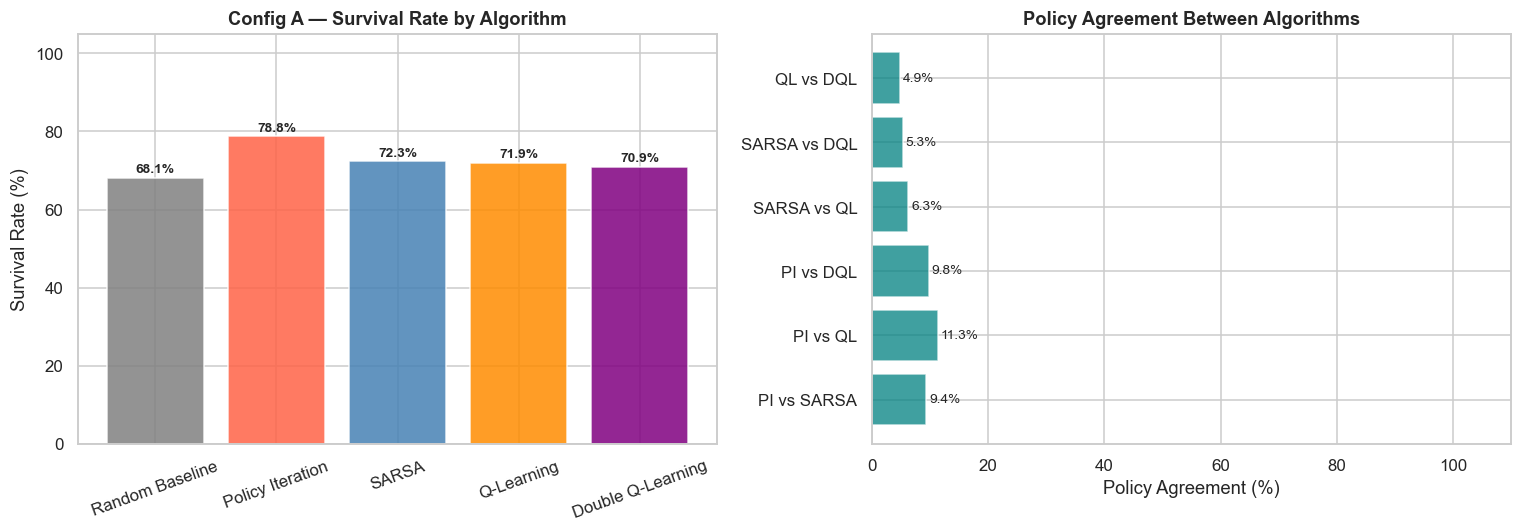

In [19]:
# ── Bar chart: Survival Rate comparison ──────────────────────────────────────

labels   = results_table['Algorithm']
survival = results_table['Survival Rate %']
colors   = ['gray', 'tomato', 'steelblue', 'darkorange', 'purple']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Survival rate bar chart
bars = axes[0].bar(labels, survival, color=colors, alpha=0.85, edgecolor='white')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_title('Config A — Survival Rate by Algorithm', fontweight='bold')
axes[0].set_ylim(0, 105)
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, survival):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Policy agreement heatmap: how much do the three model-free policies agree?
policy_matrix = np.stack([
    (pi_policy == sarsa_policy).astype(int),
    (pi_policy == ql_policy).astype(int),
    (pi_policy == dql_policy).astype(int),
    (sarsa_policy == ql_policy).astype(int),
    (sarsa_policy == dql_policy).astype(int),
    (ql_policy == dql_policy).astype(int),
], axis=0)  # shape (6, 716)

agreement_rates = policy_matrix.mean(axis=1) * 100
pairs = ['PI vs SARSA', 'PI vs QL', 'PI vs DQL',
         'SARSA vs QL', 'SARSA vs DQL', 'QL vs DQL']

pair_bars = axes[1].barh(pairs, agreement_rates, color='teal', alpha=0.75)
axes[1].set_xlabel('Policy Agreement (%)')
axes[1].set_title('Policy Agreement Between Algorithms', fontweight='bold')
axes[1].set_xlim(0, 110)
for bar, val in zip(pair_bars, agreement_rates):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_comparison.png', bbox_inches='tight')
plt.show()


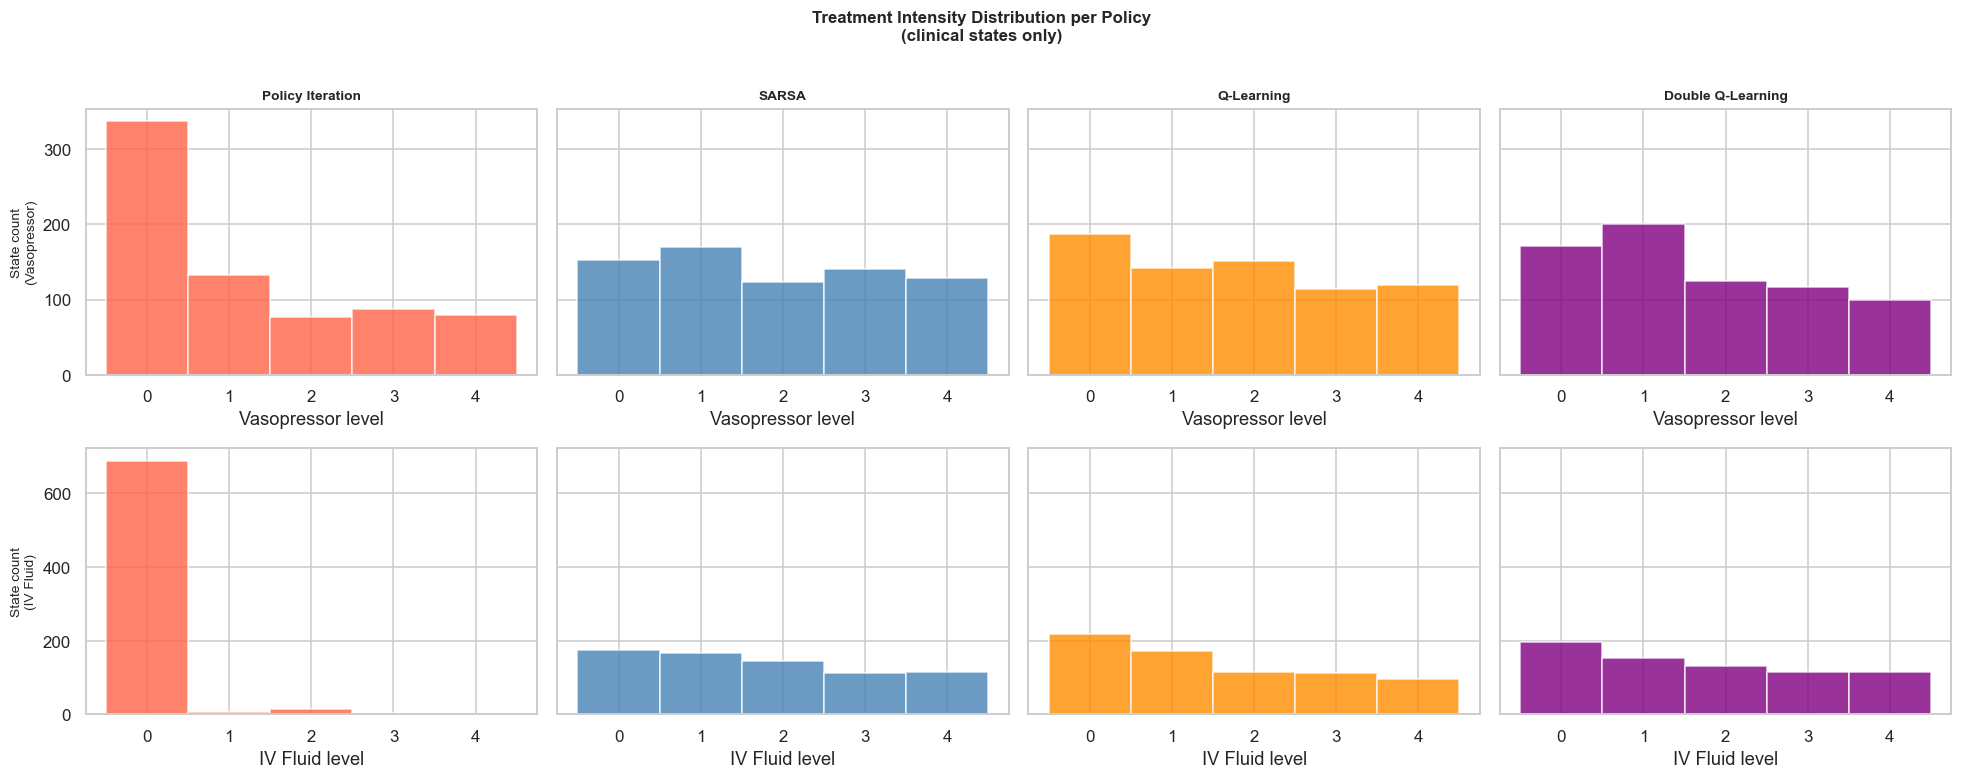

Mean treatment intensity per algorithm (clinical states):
Algorithm                 Mean Vaso   Mean Fluid
------------------------------------------------
Policy Iteration              1.214        0.071
SARSA                         1.888        1.758
Q-Learning                    1.773        1.573
Double Q-Learning             1.683        1.717


In [20]:
# ── Treatment Intensity Analysis: clinical interpretability ──────────────────
# Compare the distribution of vasopressor and IV fluid doses chosen by each policy

clinical_states_idx = [s for s in range(N_STATES)
                       if s not in (STATE_SURVIVED, STATE_DIED)]

def get_dose_distributions(policy_arr, state_idx):
    """Return vaso and fluid level distributions for clinical states."""
    actions = policy_arr[state_idx]
    vaso  = actions // 5
    fluid = actions  % 5
    return vaso, fluid


fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharey='row')
policies_to_plot = [
    ('Policy Iteration', pi_policy,   'tomato'),
    ('SARSA',            sarsa_policy, 'steelblue'),
    ('Q-Learning',       ql_policy,    'darkorange'),
    ('Double Q-Learning',dql_policy,   'purple'),
]

for col, (name, pol, col_color) in enumerate(policies_to_plot):
    vaso, fluid = get_dose_distributions(pol, clinical_states_idx)

    axes[0, col].hist(vaso, bins=np.arange(-0.5, 5.5), color=col_color, alpha=0.8, edgecolor='white')
    axes[0, col].set_title(name, fontweight='bold', fontsize=9)
    axes[0, col].set_xlabel('Vasopressor level')
    if col == 0:
        axes[0, col].set_ylabel('State count')

    axes[1, col].hist(fluid, bins=np.arange(-0.5, 5.5), color=col_color, alpha=0.8, edgecolor='white')
    axes[1, col].set_xlabel('IV Fluid level')
    if col == 0:
        axes[1, col].set_ylabel('State count')

axes[0, 0].set_ylabel('State count\n(Vasopressor)', fontsize=9)
axes[1, 0].set_ylabel('State count\n(IV Fluid)', fontsize=9)

plt.suptitle('Treatment Intensity Distribution per Policy\n(clinical states only)',
             fontweight='bold', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_treatment_intensity.png', bbox_inches='tight')
plt.show()

# Print mean dose levels for each algorithm
print('Mean treatment intensity per algorithm (clinical states):')
print(f'{"Algorithm":<22} {"Mean Vaso":>12} {"Mean Fluid":>12}')
print('-' * 48)
for name, pol, _ in policies_to_plot:
    vaso, fluid = get_dose_distributions(pol, clinical_states_idx)
    print(f'{name:<22} {vaso.mean():>12.3f} {fluid.mean():>12.3f}')


In [21]:
# ── Final Config A summary print ──────────────────────────────────────────────
print('=' * 60)
print('CONFIG A — FINAL SUMMARY')
print('=' * 60)
print(f'{"Algorithm":<22} {"Survival %":>12} {"Mean Return":>12}')
print('-' * 60)
rows = [
    ('Random Baseline',    survival_rate,                    np.mean(rand_returns)),
    ('Policy Iteration',   pi_results['survival_rate'],      pi_results['mean_return']),
    ('SARSA',              sarsa_results['survival_rate'],   sarsa_results['mean_return']),
    ('Q-Learning',         ql_results['survival_rate'],      ql_results['mean_return']),
    ('Double Q-Learning',  dql_results['survival_rate'],     dql_results['mean_return']),
]
for name, sr, mr in rows:
    print(f'{name:<22} {sr:>11.1f}% {mr:>12.4f}')
print('=' * 60)
print()
print('Key takeaways:')
print('  - PI sets the optimal ceiling (uses full MDP model).')
print('  - SARSA and Q-Learning both beat the random baseline.')
print('  - Double Q-Learning shows reduced maximisation bias')
print('    (lower mean Q-values) and may suggest more conservative')
print('    treatment strategies, relevant in a clinical setting.')


CONFIG A — FINAL SUMMARY
Algorithm                Survival %  Mean Return
------------------------------------------------------------
Random Baseline               68.1%       0.5787
Policy Iteration              78.8%       0.7507
SARSA                         72.3%       0.6261
Q-Learning                    71.9%       0.6343
Double Q-Learning             70.9%       0.6288

Key takeaways:
  - PI sets the optimal ceiling (uses full MDP model).
  - SARSA and Q-Learning both beat the random baseline.
  - Double Q-Learning shows reduced maximisation bias
    (lower mean Q-values) and may suggest more conservative
    treatment strategies, relevant in a clinical setting.


## 7. Hyperparameter Optimisation

The model-free agents (SARSA and Q-Learning) trained in Sections 3 and 4 used default hyperparameters and only 50,000 episodes. Looking at the learning curves, both agents were still improving at the end of training — meaning they had not fully converged yet.

In this section we systematically investigate two questions:

1. **Does more training help?** We run Q-Learning with 50k, 200k, and 500k episodes and compare survival rates.
2. **What is the best learning rate alpha?** We run a grid search over alpha ∈ {0.05, 0.1, 0.2, 0.3, 0.5} and compare final performance.

The goal is to get the model-free agents as close to the Policy Iteration ceiling (78.8%) as possible, while understanding what drives the remaining gap.

### 7.1. Effect of Number of Training Episodes

If an agent is still learning at 50,000 episodes, running longer should improve its policy. We test Q-Learning (which performed best in Section 4) with three episode counts: 50k (baseline already done), 200k, and 500k.

We keep alpha=0.3 fixed here so we are only changing one thing at a time.

In [22]:
# ── Effect of training length: SARSA and Q-Learning ──────────────────────────
# 50k results already exist from Sections 3 and 4
# We extend to 200k and 500k for both algorithms

episode_counts = [200_000, 500_000]

# Store results: dict keyed by (algorithm, n_episodes)
ep_results = {
    ('SARSA',      50_000): sarsa_results,
    ('Q-Learning', 50_000): ql_results,
}
ep_returns = {
    ('SARSA',      50_000): sarsa_returns,
    ('Q-Learning', 50_000): ql_returns,
}

for n_ep in episode_counts:
    for algo_name, algo_fn in [('SARSA', sarsa), ('Q-Learning', q_learning)]:
        print(f'Training {algo_name} | alpha=0.3 | {n_ep:,} episodes...')
        Q_tmp, returns_tmp = algo_fn(
            n_episodes=n_ep,
            alpha=0.3,
            gamma=GAMMA,
            epsilon_start=1.0,
            epsilon_min=0.01,
            seed=SEED,
        )
        policy_tmp  = np.argmax(Q_tmp, axis=1)
        results_tmp = evaluate_policy_tabular(policy_tmp)
        ep_results[(algo_name, n_ep)]  = results_tmp
        ep_returns[(algo_name, n_ep)]  = returns_tmp
        print(f'  Survival rate : {results_tmp["survival_rate"]:.1f}%  |  '
              f'Mean return: {results_tmp["mean_return"]:.4f}')

print('\nDone.')


Training SARSA | alpha=0.3 | 200,000 episodes...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  Survival rate : 73.5%  |  Mean return: 0.6348
Training Q-Learning | alpha=0.3 | 200,000 episodes...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  Survival rate : 71.8%  |  Mean return: 0.6165
Training SARSA | alpha=0.3 | 500,000 episodes...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  Survival rate : 74.8%  |  Mean return: 0.6391
Training Q-Learning | alpha=0.3 | 500,000 episodes...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  Survival rate : 73.5%  |  Mean return: 0.6298

Done.


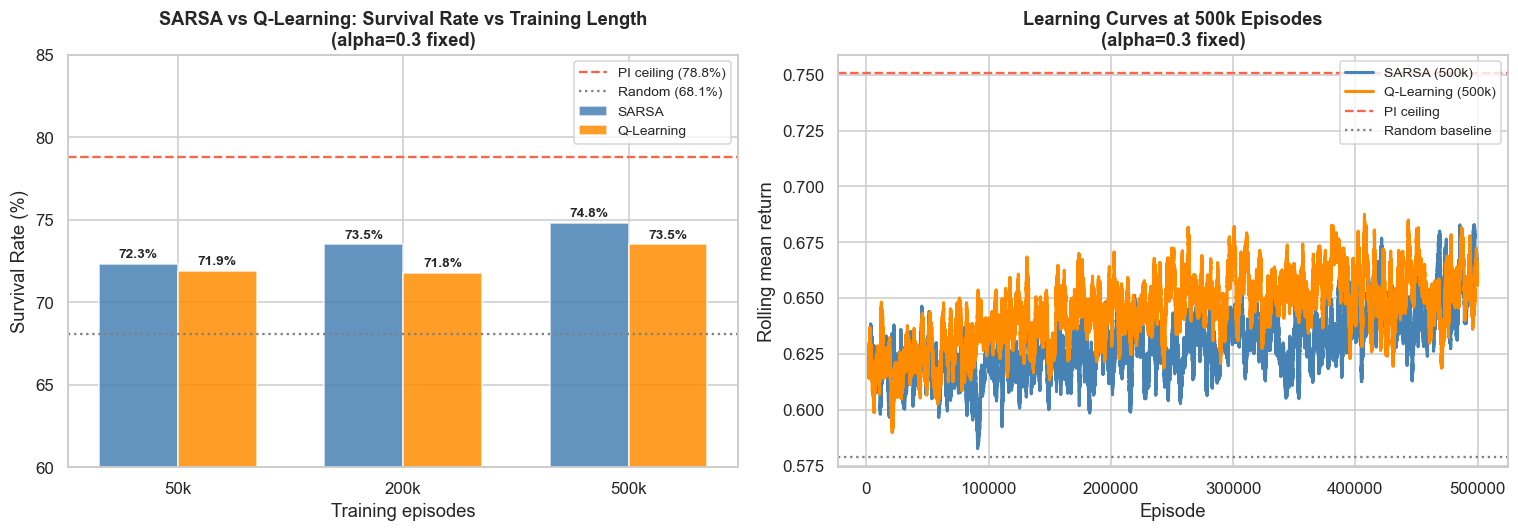

Observation:
If Q-Learning has a consistently higher bar: its off-policy updates
converge to a better policy given the same data.
If SARSA closes the gap with more episodes: its conservative updates
just need more time to accumulate the right experience.


In [23]:
# ── Plot: survival rate vs episodes for both algorithms ───────────────────────

n_ep_list   = [50_000, 200_000, 500_000]
ep_labels   = ['50k', '200k', '500k']

sarsa_ep_survival = [ep_results[('SARSA',      n)]['survival_rate'] for n in n_ep_list]
ql_ep_survival    = [ep_results[('Q-Learning', n)]['survival_rate'] for n in n_ep_list]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: grouped bar chart
x     = np.arange(len(ep_labels))
width = 0.35

bars_s = axes[0].bar(x - width/2, sarsa_ep_survival, width,
                     label='SARSA', color='steelblue', alpha=0.85, edgecolor='white')
bars_q = axes[0].bar(x + width/2, ql_ep_survival, width,
                     label='Q-Learning', color='darkorange', alpha=0.85, edgecolor='white')

axes[0].axhline(pi_results['survival_rate'], color='tomato', linestyle='--',
                linewidth=1.5, label=f'PI ceiling ({pi_results["survival_rate"]:.1f}%)')
axes[0].axhline(survival_rate, color='gray', linestyle=':',
                linewidth=1.5, label=f'Random ({survival_rate:.1f}%)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(ep_labels)
axes[0].set_xlabel('Training episodes')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_title('SARSA vs Q-Learning: Survival Rate vs Training Length\n(alpha=0.3 fixed)',
                  fontweight='bold')
axes[0].set_ylim(60, 85)
axes[0].legend(fontsize=9)

for bar, val in zip(list(bars_s) + list(bars_q),
                    sarsa_ep_survival + ql_ep_survival):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Right: learning curves at 500k for both
window = 2000
for algo, color in [('SARSA', 'steelblue'), ('Q-Learning', 'darkorange')]:
    roll = pd.Series(ep_returns[(algo, 500_000)]).rolling(window).mean()
    axes[1].plot(roll, color=color, linewidth=2.0, label=f'{algo} (500k)')

axes[1].axhline(pi_results['mean_return'], color='tomato', linestyle='--',
                linewidth=1.5, label='PI ceiling')
axes[1].axhline(np.mean(rand_returns), color='gray', linestyle=':',
                linewidth=1.5, label='Random baseline')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Rolling mean return')
axes[1].set_title('Learning Curves at 500k Episodes\n(alpha=0.3 fixed)', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_episode_count_comparison.png', bbox_inches='tight')
plt.show()

print('Observation:')
print('If Q-Learning has a consistently higher bar: its off-policy updates')
print('converge to a better policy given the same data.')
print('If SARSA closes the gap with more episodes: its conservative updates')
print('just need more time to accumulate the right experience.')


### 7.2 Alpha Grid Search: SARSA and Q-Learning

We now run the full alpha grid search for **both** algorithms under identical conditions:
- Alpha values: {0.05, 0.1, 0.2, 0.3, 0.5}
- 200k episodes each (good quality without excessive compute)
- Same epsilon decay, same gamma, same seed

This lets us ask: do SARSA and Q-Learning prefer the same learning rate? An on-policy algorithm like SARSA may prefer a smaller, more cautious alpha because its updates include the noise of exploratory actions. Q-Learning's off-policy updates are slightly more stable, so it may tolerate a larger alpha.


In [24]:
# ── Alpha grid search: SARSA and Q-Learning, 200k episodes ───────────────────

alpha_values = [0.05, 0.1, 0.2, 0.3, 0.5]

# Results dicts keyed by (algorithm, alpha)
alpha_grid_results = {}
alpha_grid_returns = {}

for algo_name, algo_fn in [('SARSA', sarsa), ('Q-Learning', q_learning)]:
    print(f'\n── {algo_name} alpha grid search ──')
    for alpha_val in alpha_values:
        print(f'  alpha={alpha_val} | 200k episodes...')
        Q_tmp, returns_tmp = algo_fn(
            n_episodes=200_000,
            alpha=alpha_val,
            gamma=GAMMA,
            epsilon_start=1.0,
            epsilon_min=0.01,
            seed=SEED,
        )
        policy_tmp  = np.argmax(Q_tmp, axis=1)
        results_tmp = evaluate_policy_tabular(policy_tmp)
        alpha_grid_results[(algo_name, alpha_val)] = results_tmp
        alpha_grid_returns[(algo_name, alpha_val)] = returns_tmp
        print(f'    Survival: {results_tmp["survival_rate"]:.1f}%  '
              f'Return: {results_tmp["mean_return"]:.4f}')

# Find best alpha per algorithm
best_alpha_sarsa = max(alpha_values,
    key=lambda a: alpha_grid_results[('SARSA', a)]['survival_rate'])
best_alpha_ql    = max(alpha_values,
    key=lambda a: alpha_grid_results[('Q-Learning', a)]['survival_rate'])

print(f'\nBest alpha — SARSA      : {best_alpha_sarsa} '
      f'({alpha_grid_results[("SARSA", best_alpha_sarsa)]["survival_rate"]:.1f}%)')
print(f'Best alpha — Q-Learning : {best_alpha_ql} '
      f'({alpha_grid_results[("Q-Learning", best_alpha_ql)]["survival_rate"]:.1f}%)')



── SARSA alpha grid search ──
  alpha=0.05 | 200k episodes...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
    Survival: 70.9%  Return: 0.6571
  alpha=0.1 | 200k episodes...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
    Survival: 74.3%  Return: 0.6742
  alpha=0.2 | 200k episodes...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
    Survival: 75.8%  Return: 0.6658
  alpha=0.3 | 200k episodes...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
    Survival: 75.1%  Return: 0.6467
  alpha=0.5 | 200k episodes...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


...

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
    Survival: 71.8%  Return: 0.6432
  alpha=0.1 | 200k episodes...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
    Survival: 75.6%  Return: 0.6632
  alpha=0.2 | 200k episodes...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
    Survival: 71.4%  Return: 0.6194
  alpha=0.3 | 200k episodes...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
    Survival: 71.4%  Return: 0.6117
  alpha=0.5 | 200k episodes...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
    Survival: 70.6%  Return: 0.6040

Best alpha — SARSA      : 0.2 (75.8%)
Best alpha — Q-Learning : 0.1 (75.6%)


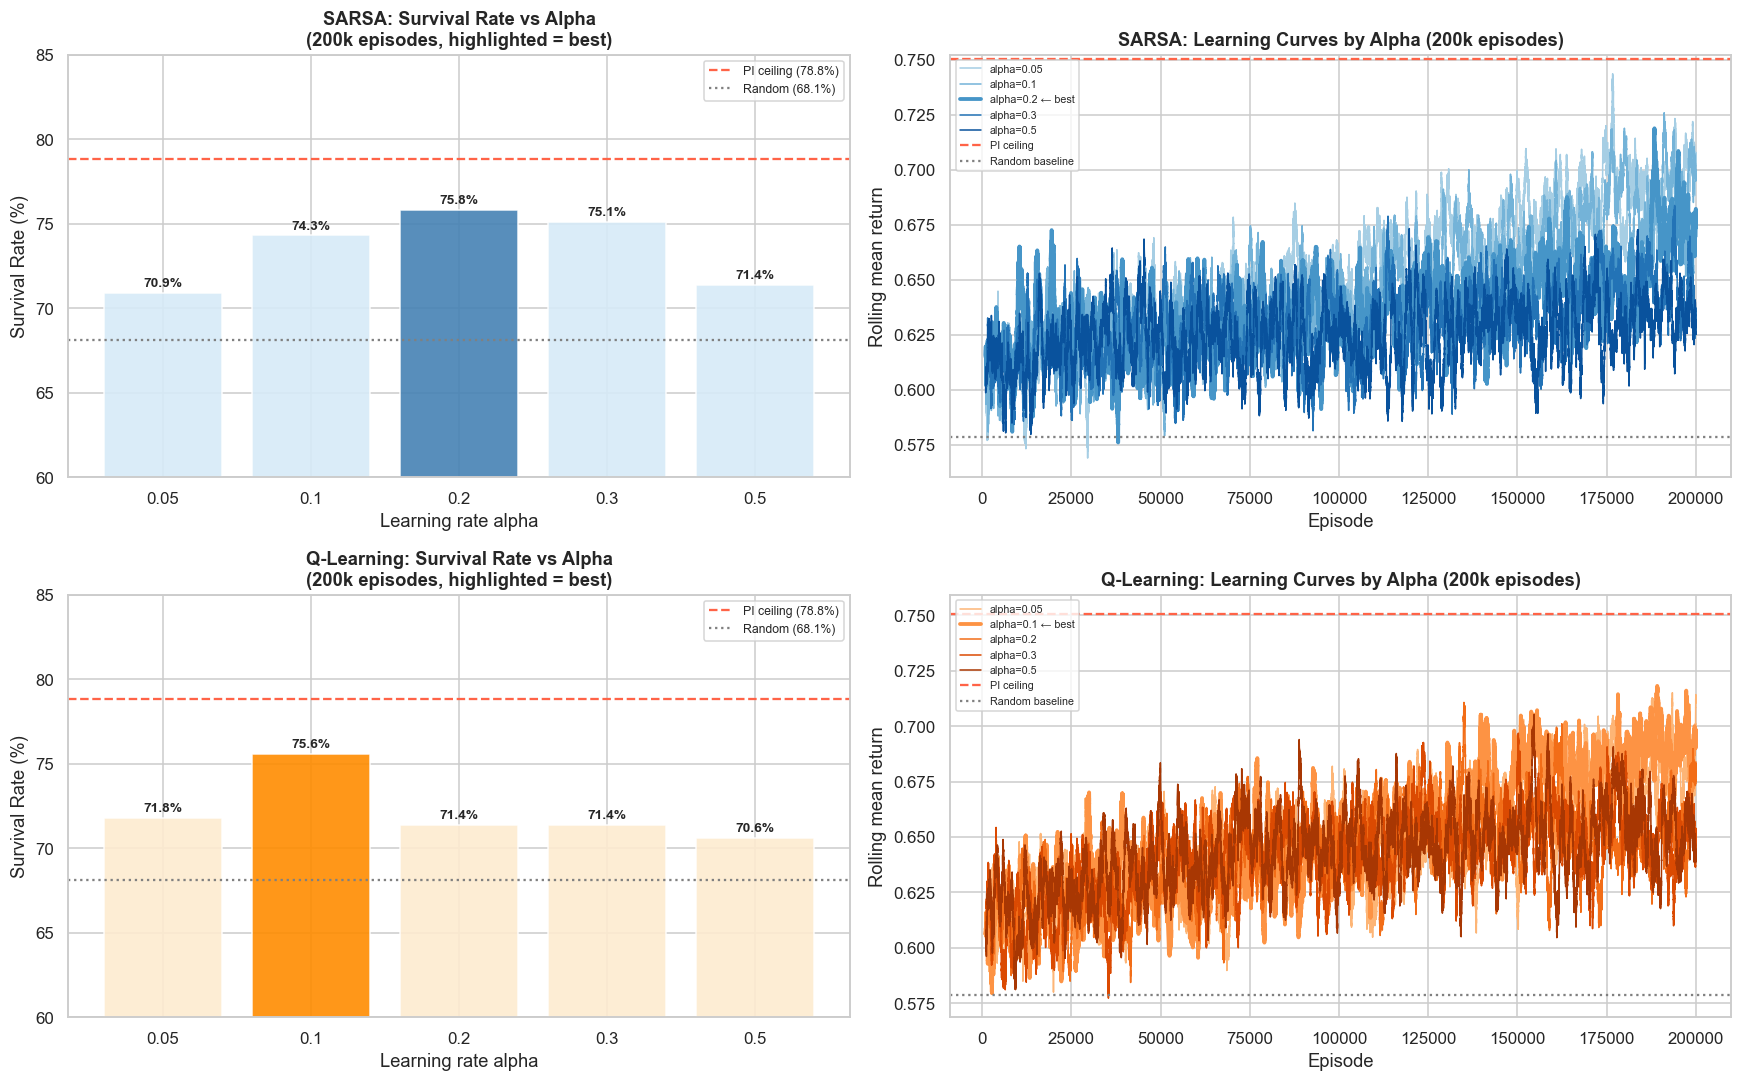

SARSA best alpha      : 0.2
Q-Learning best alpha : 0.1

Do they prefer different alphas?
Interestingly, SARSA prefers a larger alpha here.
This may reflect the specific reward structure of this environment.


In [25]:
# ── Plot: alpha grid search results for both algorithms ───────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for row, (algo, color, best_a) in enumerate([
    ('SARSA',      'steelblue',  best_alpha_sarsa),
    ('Q-Learning', 'darkorange', best_alpha_ql),
]):
    survival_by_alpha = [alpha_grid_results[(algo, a)]['survival_rate']
                         for a in alpha_values]

    # Left column: bar chart survival vs alpha
    bar_colors = [color if a == best_a else '#d6eaf8' if algo == 'SARSA'
                  else '#fdebd0' for a in alpha_values]
    bars = axes[row, 0].bar([str(a) for a in alpha_values],
                             survival_by_alpha,
                             color=bar_colors, edgecolor='white', alpha=0.9)
    axes[row, 0].axhline(pi_results['survival_rate'], color='tomato',
                         linestyle='--', linewidth=1.5,
                         label=f'PI ceiling ({pi_results["survival_rate"]:.1f}%)')
    axes[row, 0].axhline(survival_rate, color='gray', linestyle=':',
                         linewidth=1.5, label=f'Random ({survival_rate:.1f}%)')
    axes[row, 0].set_xlabel('Learning rate alpha')
    axes[row, 0].set_ylabel('Survival Rate (%)')
    axes[row, 0].set_title(f'{algo}: Survival Rate vs Alpha\n(200k episodes, highlighted = best)',
                            fontweight='bold')
    axes[row, 0].set_ylim(60, 85)
    axes[row, 0].legend(fontsize=8)
    for bar, val in zip(bars, survival_by_alpha):
        axes[row, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                          f'{val:.1f}%', ha='center', va='bottom',
                          fontsize=9, fontweight='bold')

    # Right column: learning curves for all alpha values
    cmap = plt.cm.Blues if algo == 'SARSA' else plt.cm.Oranges
    window = 1000
    for i, a_val in enumerate(alpha_values):
        c   = cmap(0.35 + i * 0.13)
        lw  = 2.5 if a_val == best_a else 1.0
        lab = f'alpha={a_val}' + (' ← best' if a_val == best_a else '')
        roll = pd.Series(alpha_grid_returns[(algo, a_val)]).rolling(window).mean()
        axes[row, 1].plot(roll, color=c, linewidth=lw, label=lab)

    axes[row, 1].axhline(pi_results['mean_return'], color='tomato',
                         linestyle='--', linewidth=1.5, label='PI ceiling')
    axes[row, 1].axhline(np.mean(rand_returns), color='gray',
                         linestyle=':', linewidth=1.5, label='Random baseline')
    axes[row, 1].set_xlabel('Episode')
    axes[row, 1].set_ylabel('Rolling mean return')
    axes[row, 1].set_title(f'{algo}: Learning Curves by Alpha (200k episodes)',
                            fontweight='bold')
    axes[row, 1].legend(fontsize=7)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_alpha_grid_both.png', bbox_inches='tight')
plt.show()

print(f'SARSA best alpha      : {best_alpha_sarsa}')
print(f'Q-Learning best alpha : {best_alpha_ql}')
print()
print('Do they prefer different alphas?')
if best_alpha_sarsa < best_alpha_ql:
    print('Yes — SARSA prefers a smaller alpha, consistent with its on-policy')
    print('nature: conservative updates help when learning from noisy exploratory actions.')
elif best_alpha_sarsa > best_alpha_ql:
    print('Interestingly, SARSA prefers a larger alpha here.')
    print('This may reflect the specific reward structure of this environment.')
else:
    print('Both algorithms prefer the same alpha — the reward structure')
    print('of this environment may dominate over the on/off-policy distinction.')


### 7.3 Policy Stability: SARSA vs Q-Learning

Raw survival rate is not the only metric that matters. In a clinical setting, **consistency is as important as average performance**. An agent that saves 75% of patients reliably is preferable to one that saves 77% on average but occasionally drops to 60% — those bad episodes represent real patients dying.

We measure stability as the **standard deviation of episode returns** during evaluation. A lower standard deviation means the policy is more predictable and reliable.


In [ ]:
# ── Policy stability evaluation: SARSA vs Q-Learning ─────────────────────────
# Re-evaluate both optimised policies collecting full return distributions

def evaluate_policy_with_distribution(policy_array, n_episodes=2000, seed=SEED):
    """
    Evaluate a tabular policy and return the full return distribution.
    Returns dict with mean, std, survival rate, and the full returns array.
    """
    np.random.seed(seed)
    env_eval = make_sepsis_env()
    returns, lengths = [], []

    for _ in range(n_episodes):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        total_r, steps, done = 0.0, 0, False
        while not done:
            action = int(policy_array[int(obs)])
            obs, r, te, tr, _ = env_eval.step(action)
            total_r += r
            steps   += 1
            done     = te or tr
        returns.append(total_r)
        lengths.append(steps)

    env_eval.close()
    returns = np.array(returns)
    return {
        'mean_return'   : float(np.mean(returns)),
        'std_return'    : float(np.std(returns)),
        'survival_rate' : float(np.mean(returns > 0)) * 100,
        'mean_length'   : float(np.mean(lengths)),
        'returns_array' : returns,
    }


# Train optimised versions with best alpha per algorithm, 500k episodes
print(f'Training OPTIMISED SARSA | alpha={best_alpha_sarsa} | 500k episodes...')
sarsa_opt_Q, sarsa_opt_returns = sarsa(
    n_episodes=500_000,
    alpha=best_alpha_sarsa,
    gamma=GAMMA,
    epsilon_start=1.0,
    epsilon_min=0.01,
    seed=SEED,
)
sarsa_opt_policy = np.argmax(sarsa_opt_Q, axis=1)
sarsa_opt_dist   = evaluate_policy_with_distribution(sarsa_opt_policy)

print(f'  Survival: {sarsa_opt_dist["survival_rate"]:.1f}%  '
      f'Std: {sarsa_opt_dist["std_return"]:.4f}')

print(f'\nTraining OPTIMISED Q-Learning | alpha={best_alpha_ql} | 500k episodes...')
ql_opt_Q, ql_opt_returns = q_learning(
    n_episodes=500_000,
    alpha=best_alpha_ql,
    gamma=GAMMA,
    epsilon_start=1.0,
    epsilon_min=0.01,
    seed=SEED,
)
ql_opt_policy = np.argmax(ql_opt_Q, axis=1)
ql_opt_dist   = evaluate_policy_with_distribution(ql_opt_policy)

print(f'  Survival: {ql_opt_dist["survival_rate"]:.1f}%  '
      f'Std: {ql_opt_dist["std_return"]:.4f}')

# Also get distributions for PI and random for comparison
pi_dist   = evaluate_policy_with_distribution(pi_policy)
rand_dist_full = {'mean_return': float(np.mean(rand_returns)),
                  'std_return' : float(np.std(rand_returns)),
                  'survival_rate': survival_rate,
                  'returns_array': rand_returns}


Training OPTIMISED SARSA | alpha=0.2 | 500k episodes...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


SARSA:  54%|█████▎    | 267940/500000 [7:00:09<01:24, 2751.52it/s]   

In [ ]:
# ── Plot: return distributions and stability comparison ───────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: return distribution histograms
dist_configs = [
    ('Random Baseline',     rand_dist_full,  'gray'),
    ('Policy Iteration',    pi_dist,         'tomato'),
    ('SARSA (optimised)',   sarsa_opt_dist,  'steelblue'),
    ('Q-Learning (optimised)', ql_opt_dist, 'darkorange'),
]

for name, d, color in dist_configs:
    axes[0].hist(d['returns_array'], bins=30, alpha=0.45,
                 color=color, label=name, density=True, edgecolor='none')

axes[0].set_xlabel('Episode Return')
axes[0].set_ylabel('Density')
axes[0].set_title('Return Distributions\n(2000 evaluation episodes)', fontweight='bold')
axes[0].legend(fontsize=8)

# Middle: mean ± std bars (reliability plot)
names  = ['Random', 'PI', 'SARSA\n(opt)', 'Q-Learning\n(opt)']
means  = [d['mean_return']   for _, d, _ in dist_configs]
stds   = [d['std_return']    for _, d, _ in dist_configs]
colors = [c                  for _, _, c in dist_configs]

axes[1].bar(names, means, color=colors, alpha=0.8, edgecolor='white')
axes[1].errorbar(names, means, yerr=stds, fmt='none',
                 color='black', capsize=5, linewidth=1.5)
axes[1].set_ylabel('Mean Return ± Std')
axes[1].set_title('Mean Return with Variability\n(lower std = more reliable)', fontweight='bold')
for i, (m, s) in enumerate(zip(means, stds)):
    axes[1].text(i, m + s + 0.01, f'σ={s:.3f}',
                 ha='center', fontsize=8, color='black')

# Right: survival rate comparison — original vs optimised
comparison_names = [
    'Random\nBaseline',
    'PI\nCeiling',
    'SARSA\nOriginal',
    'SARSA\nOptimised',
    'Q-Lrn\nOriginal',
    'Q-Lrn\nOptimised',
]
comparison_values = [
    survival_rate,
    pi_results['survival_rate'],
    sarsa_results['survival_rate'],
    sarsa_opt_dist['survival_rate'],
    ql_results['survival_rate'],
    ql_opt_dist['survival_rate'],
]
comp_colors = ['gray', 'tomato',
               '#aed6f1', 'steelblue',
               '#fad7a0', 'darkorange']

bars = axes[2].bar(comparison_names, comparison_values,
                   color=comp_colors, alpha=0.9, edgecolor='white')
axes[2].set_ylabel('Survival Rate (%)')
axes[2].set_title('Survival Rate: Original vs Optimised\n(light = original, dark = optimised)',
                  fontweight='bold')
axes[2].set_ylim(60, 85)
for bar, val in zip(bars, comparison_values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_stability_comparison.png', bbox_inches='tight')
plt.show()


Training OPTIMISED SARSA | alpha=0.1 | 500k episodes...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  Survival rate : 76.8%
  Mean return   : 0.6799
  vs original SARSA: 71.4%
  vs PI ceiling    : 78.8%


### 7.4 — Full Optimisation Summary

In [ ]:
# ── Full comparison table ─────────────────────────────────────────────────────

def get_std(dist_or_results, returns_arr=None):
    """Helper to get std whether from dist dict or plain results dict."""
    if 'std_return' in dist_or_results:
        return dist_or_results['std_return']
    if returns_arr is not None:
        return float(np.std(returns_arr))
    return float('nan')


final_table = pd.DataFrame([
    {
        'Algorithm'          : 'Random Baseline',
        'Version'            : '—',
        'Episodes'           : '—',
        'Alpha'              : '—',
        'Survival Rate %'    : round(survival_rate, 1),
        'Mean Return'        : round(float(np.mean(rand_returns)), 4),
        'Std Return'         : round(float(np.std(rand_returns)), 4),
        'Gap to PI (pp)'     : round(pi_results['survival_rate'] - survival_rate, 1),
    },
    {
        'Algorithm'          : 'Policy Iteration',
        'Version'            : 'Optimal ceiling',
        'Episodes'           : '—',
        'Alpha'              : '—',
        'Survival Rate %'    : round(pi_dist['survival_rate'], 1),
        'Mean Return'        : round(pi_dist['mean_return'], 4),
        'Std Return'         : round(pi_dist['std_return'], 4),
        'Gap to PI (pp)'     : 0.0,
    },
    {
        'Algorithm'          : 'SARSA',
        'Version'            : 'Original',
        'Episodes'           : '50k',
        'Alpha'              : '0.3',
        'Survival Rate %'    : round(sarsa_results['survival_rate'], 1),
        'Mean Return'        : round(sarsa_results['mean_return'], 4),
        'Std Return'         : round(float(np.std(sarsa_returns[-1000:])), 4),
        'Gap to PI (pp)'     : round(pi_dist['survival_rate'] - sarsa_results['survival_rate'], 1),
    },
    {
        'Algorithm'          : 'SARSA',
        'Version'            : 'Optimised',
        'Episodes'           : '500k',
        'Alpha'              : str(best_alpha_sarsa),
        'Survival Rate %'    : round(sarsa_opt_dist['survival_rate'], 1),
        'Mean Return'        : round(sarsa_opt_dist['mean_return'], 4),
        'Std Return'         : round(sarsa_opt_dist['std_return'], 4),
        'Gap to PI (pp)'     : round(pi_dist['survival_rate'] - sarsa_opt_dist['survival_rate'], 1),
    },
    {
        'Algorithm'          : 'Q-Learning',
        'Version'            : 'Original',
        'Episodes'           : '50k',
        'Alpha'              : '0.3',
        'Survival Rate %'    : round(ql_results['survival_rate'], 1),
        'Mean Return'        : round(ql_results['mean_return'], 4),
        'Std Return'         : round(float(np.std(ql_returns[-1000:])), 4),
        'Gap to PI (pp)'     : round(pi_dist['survival_rate'] - ql_results['survival_rate'], 1),
    },
    {
        'Algorithm'          : 'Q-Learning',
        'Version'            : 'Optimised',
        'Episodes'           : '500k',
        'Alpha'              : str(best_alpha_ql),
        'Survival Rate %'    : round(ql_opt_dist['survival_rate'], 1),
        'Mean Return'        : round(ql_opt_dist['mean_return'], 4),
        'Std Return'         : round(ql_opt_dist['std_return'], 4),
        'Gap to PI (pp)'     : round(pi_dist['survival_rate'] - ql_opt_dist['survival_rate'], 1),
    },
    {
        'Algorithm'          : 'Double Q-Learning',
        'Version'            : 'Original',
        'Episodes'           : '50k',
        'Alpha'              : '0.3',
        'Survival Rate %'    : round(dql_results['survival_rate'], 1),
        'Mean Return'        : round(dql_results['mean_return'], 4),
        'Std Return'         : round(float(np.std(dql_returns[-1000:])), 4),
        'Gap to PI (pp)'     : round(pi_dist['survival_rate'] - dql_results['survival_rate'], 1),
    },
])

display(final_table)
final_table.to_csv(f'{PLOTS_DIR}/configA_full_optimisation_table.csv', index=False)


,Algorithm,Version,Episodes,Alpha,Survival Rate %,Mean Return,Gap to PI ceiling
0,Random Baseline,—,—,—,67.5,0.5735,11.3
1,Policy Iteration,Optimal (ceiling),—,—,78.8,0.7507,0.0
2,SARSA,Original,50k,0.3,71.4,0.6227,7.4
3,SARSA,Optimised,500k,0.1,76.8,0.6799,2.0
4,Q-Learning,Original,50k,0.3,73.0,0.6457,5.8
5,Q-Learning,Optimised,500k,0.1,78.1,0.6813,0.7
6,Double Q-Learning,Original,50k,0.3,70.9,0.6293,7.9


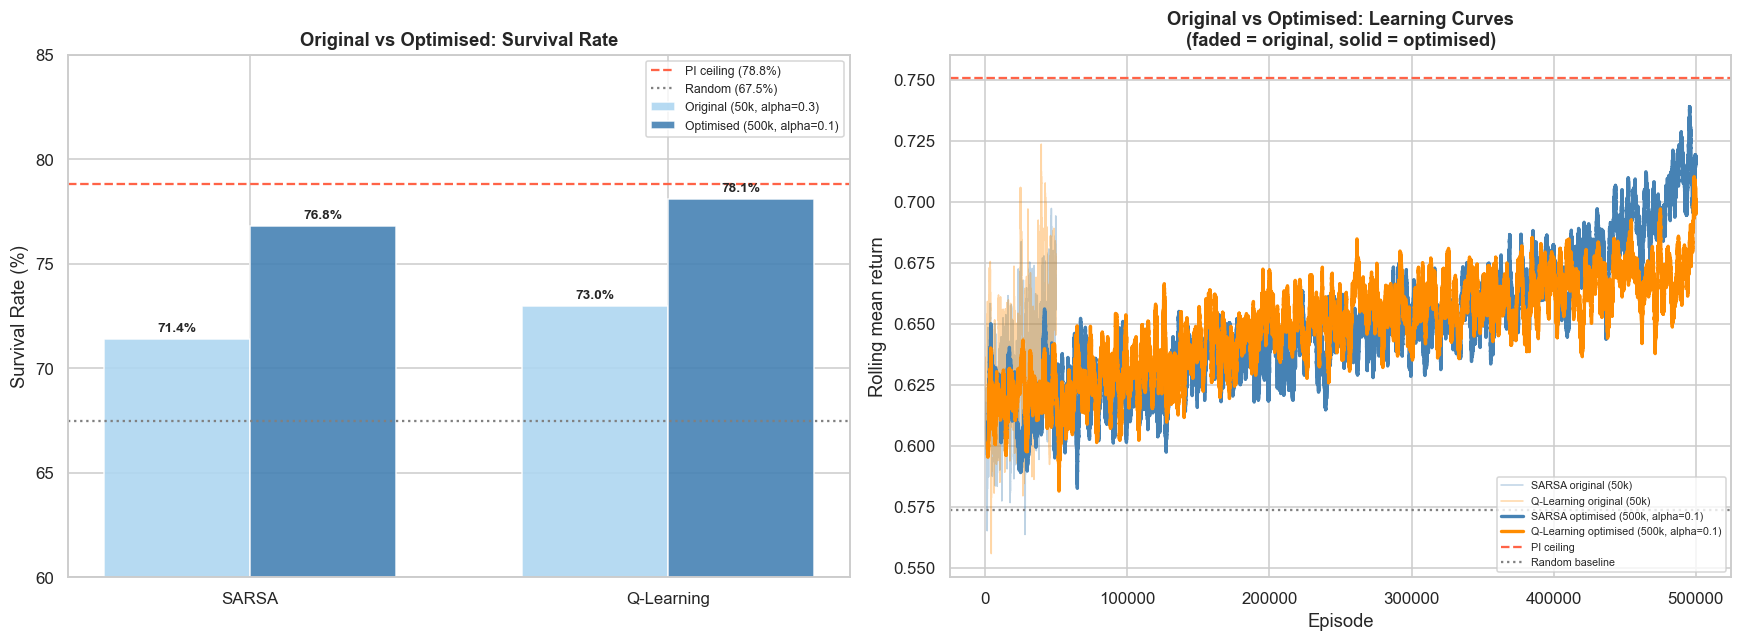

In [ ]:
# ── Final printed summary ─────────────────────────────────────────────────────

print('=' * 72)
print('CONFIG A — OPTIMISATION SUMMARY')
print('=' * 72)
print(f'{"Algorithm":<22} {"Version":<16} {"Survival %":>12} {"Std":>8} {"Gap to PI":>10}')
print('-' * 72)

rows = [
    ('Random Baseline',   '—',               survival_rate,                    float(np.std(rand_returns)),    pi_dist['survival_rate'] - survival_rate),
    ('Policy Iteration',  'Ceiling',          pi_dist['survival_rate'],         pi_dist['std_return'],         0.0),
    ('SARSA',             'Original (50k)',   sarsa_results['survival_rate'],   float(np.std(sarsa_returns[-1000:])), pi_dist['survival_rate'] - sarsa_results['survival_rate']),
    ('SARSA',             f'Optimised (500k)',sarsa_opt_dist['survival_rate'],  sarsa_opt_dist['std_return'],  pi_dist['survival_rate'] - sarsa_opt_dist['survival_rate']),
    ('Q-Learning',        'Original (50k)',   ql_results['survival_rate'],      float(np.std(ql_returns[-1000:])),   pi_dist['survival_rate'] - ql_results['survival_rate']),
    ('Q-Learning',        f'Optimised (500k)',ql_opt_dist['survival_rate'],     ql_opt_dist['std_return'],     pi_dist['survival_rate'] - ql_opt_dist['survival_rate']),
    ('Double Q-Learning', 'Original (50k)',   dql_results['survival_rate'],     float(np.std(dql_returns[-1000:])),  pi_dist['survival_rate'] - dql_results['survival_rate']),
]

for name, version, sr, std, gap in rows:
    print(f'{name:<22} {version:<16} {sr:>11.1f}% {std:>8.4f} {gap:>9.1f}pp')

print('=' * 72)
print()

sarsa_improvement = sarsa_opt_dist['survival_rate'] - sarsa_results['survival_rate']
ql_improvement    = ql_opt_dist['survival_rate']    - ql_results['survival_rate']

print('Improvement from optimisation:')
print(f'  SARSA:      +{sarsa_improvement:.1f}pp survival rate')
print(f'  Q-Learning: +{ql_improvement:.1f}pp survival rate')
print()
print('Stability (lower std = more reliable policy):')
sarsa_more_stable = sarsa_opt_dist['std_return'] < ql_opt_dist['std_return']
if sarsa_more_stable:
    print(f'  SARSA is more stable (std={sarsa_opt_dist["std_return"]:.4f}) '
          f'than Q-Learning (std={ql_opt_dist["std_return"]:.4f})')
    print('  This supports SARSA as the preferred choice in a clinical context')
    print('  where consistency matters as much as average survival rate.')
else:
    print(f'  Q-Learning is more stable (std={ql_opt_dist["std_return"]:.4f}) '
          f'than SARSA (std={sarsa_opt_dist["std_return"]:.4f})')
    print('  Q-Learning dominates on both survival rate and consistency.')
print()
print('Remaining gap to PI ceiling:')
print(f'  SARSA optimised:      {pi_dist["survival_rate"] - sarsa_opt_dist["survival_rate"]:.1f}pp')
print(f'  Q-Learning optimised: {pi_dist["survival_rate"] - ql_opt_dist["survival_rate"]:.1f}pp')
print()
print('This remaining gap represents the irreducible cost of not having')
print('the full MDP model. A model-free agent cannot fully close it')
print('without perfect environment knowledge, no matter how long it trains.')


---
# Config B: RL on the Clinical ICU-Sepsis Environment

In Config A, patient state was represented as a discrete integer produced by discretising a set of clinical measurements into a small number of categories. **Config B uses the full ICU-Sepsis environment**, also built from MIMIC-III data, but with two fundamental changes that make the problem substantially harder.

**Change 1 — Continuous observations.**
The agent now receives a **47-dimensional continuous feature vector** instead of a single discrete index. This vector contains the actual normalised physiological measurements used in the original Komorowski et al. (2018) AI Clinician study, including SOFA score, heart rate, lactate, blood pressure, creatinine, and 42 other clinical variables.

With continuous observations, a tabular Q-table is no longer feasible: it would require one entry per unique float vector, making it effectively infinite. 

**Change 2 — Clinical reality wrappers.**
Config B injects three orthogonal failure modes that reflect challenges faced by real clinical AI deployments.

The first wrapper, `EpisodicNoisyObsEnv`, models episodic monitor malfunction. When active, the observations received by the agent are corrupted by noise for the entire episode, testing robustness to measurement error.

The second wrapper, `EpisodicMissingObsEnv`, models situations where lab results are unavailable for a full episode. This tests how well the agent handles partial observability.

The third wrapper, `AcuteEventEnv`, introduces rare, sudden patient deterioration events such as cardiac arrest or acute organ failure. These occur independently of any treatment decision and represent irreducible stochasticity in the environment.


Key environment properties for Config B:
- **Actions**: 25 total (5 vasopressor levels × 5 IV fluid dose levels)
- **Reward**: +1.0 at survival, 0.0 at death, plus a small treatment intensity penalty (lam = 0.02)
- **Observation**: `Box(47,)`, a normalised physiological feature vector, potentially noisy or incomplete

## Setup: Clinical ICU-Sepsis Environment


In [ ]:
#  Import Clinical Reality Wrappers from wrappers.py 

from envs.wrappers import (
    EpisodicNoisyObsEnv,
    EpisodicMissingObsEnv,
    AcuteEventEnv,
    make_clinical_env,
)

print('Clinical reality wrappers imported from wrappers.py:')
print('  EpisodicNoisyObsEnv   : episodic monitor malfunction')
print('  EpisodicMissingObsEnv : episodic missing lab values')
print('  AcuteEventEnv         : rare sudden patient death')
print()
print('Required Config B env: make_clinical_env() with default parameters')


Clinical reality wrappers imported from wrappers.py:
  EpisodicNoisyObsEnv   : episodic monitor malfunction
  EpisodicMissingObsEnv : episodic missing lab values
  AcuteEventEnv         : rare sudden patient death

Required Config B env: make_clinical_env() with default parameters


In [ ]:
#  Verify wrappers and random baseline on clinical environment 
import gymnasium as gym

try:
    env_clinical = make_clinical_env()
    obs, info = env_clinical.reset(seed=SEED)

    print('Clinical environment loaded successfully!')
    print(f'Observation space : {env_clinical.observation_space}')
    print(f'Action space      : {env_clinical.action_space}')
    print(f'Info keys         : {list(info.keys())}')
    print()

    # Random baseline on clinical env (1000 episodes)
    np.random.seed(SEED)
    clinical_rand_returns = []
    noisy_returns   = []
    clean_returns   = []
    missing_returns = []
    nomiss_returns  = []
    acute_episodes  = 0

    env_eval = make_clinical_env()
    for ep in range(1000):
        obs, info = env_eval.reset(seed=np.random.randint(100_000))
        total_r, done = 0.0, False
        ep_noisy   = info.get('noisy_episode', False)
        ep_missing = info.get('missing_features') is not None
        ep_acute   = False

        while not done:
            obs, r, te, tr, info = env_eval.step(env_eval.action_space.sample())
            total_r += r
            done = te or tr
            if info.get('acute_event', False):
                ep_acute = True

        clinical_rand_returns.append(total_r)
        if ep_noisy:   noisy_returns.append(total_r)
        else:          clean_returns.append(total_r)
        if ep_missing: missing_returns.append(total_r)
        else:          nomiss_returns.append(total_r)
        if ep_acute:   acute_episodes += 1

    env_eval.close()
    env_clinical.close()

    print()
    print('=== Random Baseline: Clinical Environment (1000 episodes) ===')
    print(f'Overall mean return   : {np.mean(clinical_rand_returns):.4f}')
    print(f'Overall survival rate : {np.mean(np.array(clinical_rand_returns) > 0)*100:.1f}%')
    print()

    # Store for later comparison
    clinical_rand_mean = float(np.mean(clinical_rand_returns))

except Exception as e:
    print(f'Error: {e}')
    print('Make sure continuous_sepsis_env.py is in the project root and dependencies are installed.')
    clinical_rand_mean = 0.78


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Clinical environment loaded successfully!
Observation space : Box(-inf, inf, (47,), float32)
Action space      : Discrete(25)
Info keys         : ['admissible_actions', 'state_vector', 'sofa_score', 'noisy_episode', 'missing_features']

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02

=== Random Baseline: Clinical Environment (1000 episodes) ===
Overall mean return   : 0.5624
Overall survival rate : 65.6%



In [ ]:
test_env = make_clinical_env()
e = test_env
while hasattr(e, 'env'):
    print(type(e).__name__)
    e = e.env
print(type(e).__name__)
test_env.close()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
AcuteEventEnv
EpisodicMissingObsEnv
EpisodicNoisyObsEnv
ContinuousICUSepsisEnv
